# **Limpieza y análisis exploratorio del DataFrame 1: actividad de clientes**

## **1. Carga de datos**

In [1]:
# Importación de librerías necesarias para análisis y visualización de datos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Carga del dataset
df = pd.read_csv("../data/customer_activity.csv")

# Vista inicial del dataset
df.head()

,customer_id,first_name,last_name,email,active,address,district,postal_code,city,country,rental_id,rental_date,return_date,payment_id,payment_date,amount,rental_duration
0,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2005-05-25 11:30:37,2.99,9
1,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,2005-05-28 10:35:23,0.99,6
2,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,2005-06-15 00:54:12,5.99,8
3,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,2005-06-15 18:02:53,0.99,4
4,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,2005-06-15 21:08:46,9.99,10


## **2. Analisis exploratorio**

### **2.1 Información general**

In [3]:
df.shape

(15861, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      15861 non-null  int64  
 1   first_name       15861 non-null  object 
 2   last_name        15861 non-null  object 
 3   email            15861 non-null  object 
 4   active           15861 non-null  int64  
 5   address          15861 non-null  object 
 6   district         15761 non-null  object 
 7   postal_code      15861 non-null  int64  
 8   city             15861 non-null  object 
 9   country          15861 non-null  object 
 10  rental_id        15861 non-null  int64  
 11  rental_date      15861 non-null  object 
 12  return_date      15861 non-null  object 
 13  payment_id       15861 non-null  int64  
 14  payment_date     15861 non-null  object 
 15  amount           15861 non-null  float64
 16  rental_duration  15861 non-null  int64  
dtypes: float64(1

El dataset contiene 15.861 registros y 17 columnas.

En cuanto a tipos de datos, se observa que varias columnas de fecha (`rental_date`, `return_date`, `payment_date`) están almacenadas como tipo `object`, por lo que será necesario convertirlas a `datetime` para su correcto tratamiento.

### **2.2 Valores nulos**

In [5]:
df.isnull().sum()

customer_id          0
first_name           0
last_name            0
email                0
active               0
address              0
district           100
postal_code          0
city                 0
country              0
rental_id            0
rental_date          0
return_date          0
payment_id           0
payment_date         0
amount               0
rental_duration      0
dtype: int64

Se detectan valores nulos únicamente en la columna `district`, con un total de 100 registros afectados.

### **2.3 Duplicados**

In [6]:
df.duplicated().sum()

np.int64(0)

No se han detectado registros duplicados en el dataset (0 duplicados), lo que indica que la combinación de JOINs en SQL no ha generado repeticiones.

### **2.4 Estadísticas básicas**

In [7]:
df.describe()

,customer_id,active,postal_code,rental_id,payment_id,amount,rental_duration
count,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000
mean,297.259567,0.974781,50452.519324,7959.654562,8027.491268,4.217161,5.025219
std,172.375305,0.156795,28910.703531,4616.463306,4630.658068,2.360383,2.611835
min,1.000000,0.000000,3.000000,1.000000,1.000000,0.990000,0.000000
25%,148.000000,1.000000,25238.000000,3968.000000,4015.000000,2.990000,3.000000
50%,296.000000,1.000000,51309.000000,7934.000000,8033.000000,3.990000,5.000000
75%,446.000000,1.000000,75149.000000,11920.000000,12036.000000,4.990000,7.000000
max,599.000000,1.000000,99865.000000,16049.000000,16049.000000,11.990000,10.000000


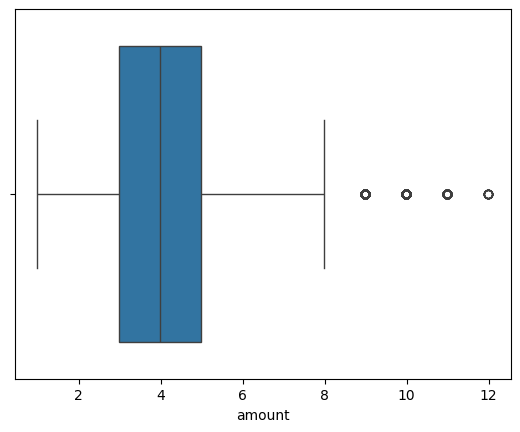

In [8]:
sns.boxplot(x=df['amount'])
plt.show()

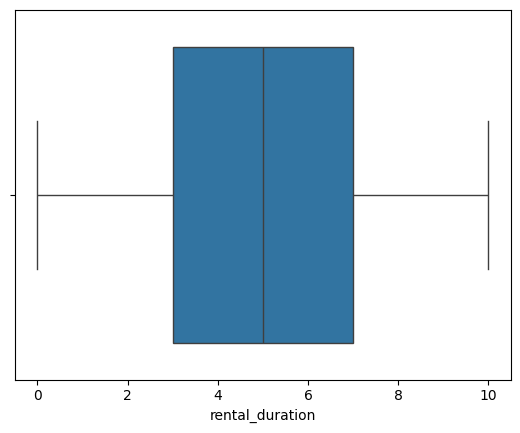

In [9]:
sns.boxplot(x=df['rental_duration'])
plt.show()

Se han analizado las variables `amount` y `rental_duration` por ser métricas clave para entender el comportamiento del dataset.

En `amount`, tanto el análisis descriptivo como el boxplot muestran una concentración de valores entre 2.99 y 4.99, con algunos valores superiores que podrían considerarse atípicos, aunque no extremadamente alejados del rango habitual.

En `rental_duration`, la distribución se concentra principalmente entre 3 y 7 días, sin presencia de valores fuera de los límites del boxplot, lo que indica una distribución estable y sin outliers estadísticamente relevantes.

## **3. Limpieza de datos**

### **3.1 Conversión de fechas a datetime**

In [10]:
# Conversión a datetime
df['rental_date'] = pd.to_datetime(df['rental_date'], errors='coerce')
df['return_date'] = pd.to_datetime(df['return_date'], errors='coerce')
df['payment_date'] = pd.to_datetime(df['payment_date'], errors='coerce')

# Verificamos si hay nulos después de la conversión
print(f"Nulos en rental_date: {df['rental_date'].isna().sum()}")
print(f"Nulos en return_date: {df['return_date'].isna().sum()}")
print(f"Nulos en payment_date: {df['payment_date'].isna().sum()}")

# Si hay nulos, los eliminamos para poder operar
df = df.dropna(subset=['rental_date', 'return_date'])

Nulos en rental_date: 0
Nulos en return_date: 0
Nulos en payment_date: 0


In [11]:
# Comprobación de que las columnas han sido convertidas a datetime
df[['rental_date', 'return_date', 'payment_date']].dtypes

rental_date     datetime64[ns]
return_date     datetime64[ns]
payment_date    datetime64[ns]
dtype: object

### **3.2 Verificación de duplicados**

In [12]:
# Eliminación de duplicados (por seguridad)
df = df.drop_duplicates()

# Verificación posterior
duplicados_final = df.duplicated().sum()
print(f"Número de duplicados después de la eliminación: {duplicados_final}")

Número de duplicados después de la eliminación: 0


El análisis nos confirmó que no existían registros duplicados en el dataset.

Este paso se realiza como validación adicional, asegurando la integridad de los datos tras el proceso de limpieza.

### **3.3 Tratamiento de valores nulos**

In [13]:
# Sustitución de valores nulos en la columna 'district' por una etiqueta descriptiva
df['district'] = df['district'].fillna('Sin Datos')

# Comprobación de que ya no existen valores nulos en la columna
print(df['district'].isnull().sum())

0


Los valores nulos presentes en la columna `district` se han sustituido por la etiqueta "Sin Datos".

Esta decisión se toma debido a que se trata de una variable categórica no crítica para el análisis principal, y el porcentaje de valores faltantes es reducido. Sustituirlos permite mantener la integridad del dataset sin eliminar registros útiles.

### **3.4 Normalizar cadenas**

In [14]:
# Normalización de variables de tipo texto: conversión a minúsculas y eliminación de espacios
columnas_texto = df.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df[col] = df[col].str.lower().str.strip()

df.head()

,customer_id,first_name,last_name,email,active,address,district,postal_code,city,country,rental_id,rental_date,return_date,payment_id,payment_date,amount,rental_duration
0,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2005-05-25 11:30:37,2.99,9
1,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,2005-05-28 10:35:23,0.99,6
2,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,2005-06-15 00:54:12,5.99,8
3,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,2005-06-15 18:02:53,0.99,4
4,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,2005-06-15 21:08:46,9.99,10


### **3.5 Corregir tipos numericos**

In [15]:
# Conversión de código postal a string para tratarlo como variable categórica
df['postal_code'] = df['postal_code'].astype(str)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      15861 non-null  int64         
 1   first_name       15861 non-null  object        
 2   last_name        15861 non-null  object        
 3   email            15861 non-null  object        
 4   active           15861 non-null  int64         
 5   address          15861 non-null  object        
 6   district         15861 non-null  object        
 7   postal_code      15861 non-null  object        
 8   city             15861 non-null  object        
 9   country          15861 non-null  object        
 10  rental_id        15861 non-null  int64         
 11  rental_date      15861 non-null  datetime64[ns]
 12  return_date      15861 non-null  datetime64[ns]
 13  payment_id       15861 non-null  int64         
 14  payment_date     15861 non-null  datet

### **3.6 Detectar outliers**

A partir del análisis de `describe()` y de los diagramas de caja (boxplots), se observa que la variable `amount` presenta algunos valores por encima del rango intercuartílico, identificados como posibles valores atípicos.

Sin embargo, estos valores corresponden a transacciones reales del sistema, por lo que no se consideran errores de datos.

En el caso de `rental_duration`, la distribución se mantiene estable y no se observan valores atípicos relevantes.

Por este motivo, no se realiza eliminación de registros, ya que los valores extremos forman parte del comportamiento natural del dataset.

### **3.7 Crear columna derivadas**

In [16]:
# Creación de variable derivada: día de la semana del pago
# Permite analizar patrones de comportamiento según el día
df['payment_weekday'] = df['payment_date'].dt.day_name()

df.head()

,customer_id,first_name,last_name,email,active,address,district,postal_code,city,country,rental_id,rental_date,return_date,payment_id,payment_date,amount,rental_duration,payment_weekday
0,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2005-05-25 11:30:37,2.99,9,Wednesday
1,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,2005-05-28 10:35:23,0.99,6,Saturday
2,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,2005-06-15 00:54:12,5.99,8,Wednesday
3,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,2005-06-15 18:02:53,0.99,4,Wednesday
4,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,sasebo,japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,2005-06-15 21:08:46,9.99,10,Wednesday


## **4. Visualización de datos**

### **4.1 Distribución de los importes de pago** ###

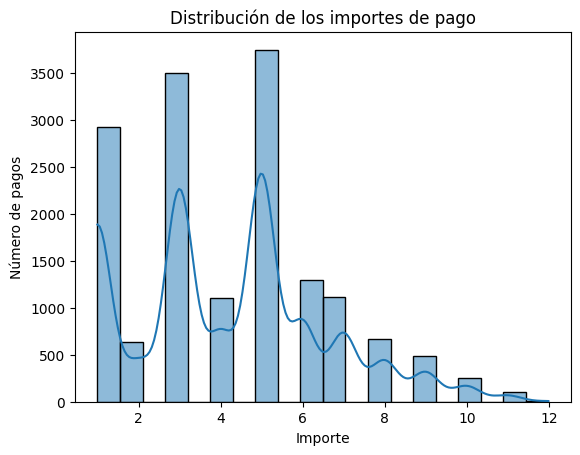

In [17]:
sns.histplot(df['amount'], bins=20, kde=True, label="Histograma + KDE")

plt.title("Distribución de los importes de pago")
plt.xlabel("Importe")
plt.ylabel("Número de pagos")

plt.show()

El gráfico muestra que los importes de pago no se distribuyen de forma uniforme, sino que aparecen concentraciones claras en valores concretos (especialmente alrededor de 1–6 unidades), con picos repetidos en esos importes.

A medida que el importe aumenta (a partir de 7–12), la frecuencia de pagos disminuye notablemente, lo que indica una distribución sesgada a la derecha: muchos pagos pequeños y pocos pagos grandes. La línea suavizada refuerza esta tendencia general y ayuda a ver que la mayor parte de las transacciones se concentran en importes bajos-medios.

### **4.2 Frecuencia de duración del alquiler**

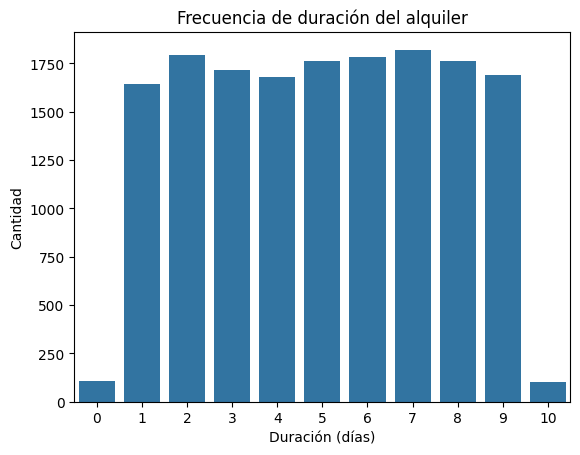

In [21]:
sns.countplot(x=df['rental_duration'])
plt.title("Frecuencia de duración del alquiler")
plt.xlabel("Duración (días)")
plt.ylabel("Cantidad")
plt.show()

La duración de los alquileres oscila entre 0 y 10 días y se reparte de forma bastante homogénea, lo que sugiere que no existe una preferencia clara por un número concreto de días.

### **4.3 Distribución de pagos por día de la semana**

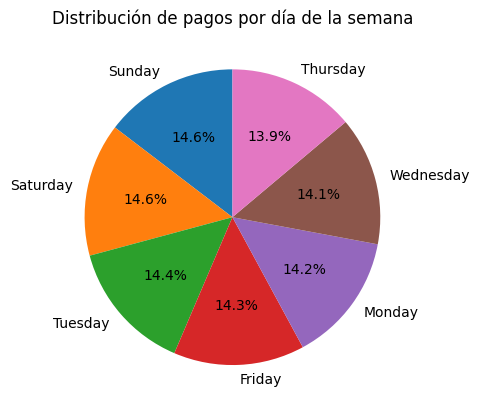

In [22]:
df['payment_weekday'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribución de pagos por día de la semana")
plt.ylabel("")  # quita la etiqueta fea del eje Y
plt.show()

“La distribución de pagos por día de la semana es bastante homogénea, lo que indica que no existe un patrón claro de concentración en días específicos.

### **4.4 Tendencia del pago según duración**

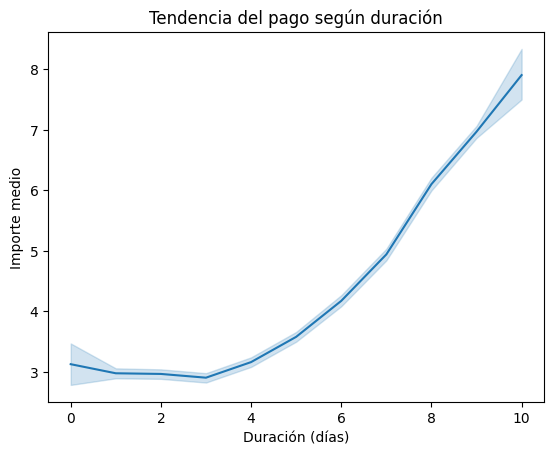

In [27]:
sns.lineplot(x='rental_duration', y='amount', data=df, estimator='mean')
plt.title("Tendencia del pago según duración")
plt.xlabel("Duración (días)")
plt.ylabel("Importe medio")
plt.show()

Se observa una estructura de precios escalonada: tarifas bajas y estables para alquileres cortos (hasta 4 días) y un incremento progresivo del coste a medida que aumenta la duración.

## **5. Conclusiones finales**

Se ha realizado la extracción y limpieza de datos de la tabla de actividad de clientes de la base de datos Sakila, generando un dataset unificado mediante SQL y Python. Posteriormente, se ha analizado el comportamiento de los clientes en relación a la duración de los alquileres y los pagos, observándose patrones estables en los alquileres cortos y un incremento del importe a medida que aumenta la duración.